In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv(r'/content/video_games_sales.csv')
print (df)

        Rank                                              Name Platform  \
0          1                                        Wii Sports      Wii   
1          2                                 Super Mario Bros.      NES   
2          3                                    Mario Kart Wii      Wii   
3          4                                 Wii Sports Resort      Wii   
4          5                          Pokemon Red/Pokemon Blue       GB   
...      ...                                               ...      ...   
16593  16596                Woody Woodpecker in Crazy Castle 5      GBA   
16594  16597                     Men in Black II: Alien Escape       GC   
16595  16598  SCORE International Baja 1000: The Official Game      PS2   
16596  16599                                        Know How 2       DS   
16597  16600                                  Spirits & Spells      GBA   

         Year         Genre   Publisher  NA_Sales  EU_Sales  JP_Sales  \
0      2006.0        Sport

In [ ]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [3]:
onlysalescolumns = ['NA_Sales','EU_Sales','JP_Sales','Other_Sales','Global_Sales']
(df[onlysalescolumns].describe())

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,0.264667,0.146652,0.077782,0.048063,0.537441
std,0.816683,0.505351,0.309291,0.188588,1.555028
min,0.000000,0.000000,0.000000,0.000000,0.010000
25%,0.000000,0.000000,0.000000,0.000000,0.060000
50%,0.080000,0.020000,0.000000,0.010000,0.170000
75%,0.240000,0.110000,0.040000,0.040000,0.470000
max,41.490000,29.020000,10.220000,10.570000,82.740000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [5]:
print (df.head(10))

   Rank                       Name Platform    Year         Genre Publisher  \
0     1                 Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2          Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3             Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
3     4          Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
4     5   Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   
5     6                     Tetris       GB  1989.0        Puzzle  Nintendo   
6     7      New Super Mario Bros.       DS  2006.0      Platform  Nintendo   
7     8                   Wii Play      Wii  2006.0          Misc  Nintendo   
8     9  New Super Mario Bros. Wii      Wii  2009.0      Platform  Nintendo   
9    10                  Duck Hunt      NES  1984.0       Shooter  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0     41.49     29.02      3.77         8.46         82.74  
1     29

In [6]:
print (df.shape[0])
print (df.shape[1])


16598
11


In [ ]:
#檢查有冇重覆
print (df.duplicated())
print ('the total number of duplicated is', df.duplicated().sum())

0        False
1        False
2        False
3        False
4        False
         ...  
16593    False
16594    False
16595    False
16596    False
16597    False
Length: 16598, dtype: bool
the total number of duplicated is 0


In [7]:
games_with_missing_years = df[df['Year'].isnull()]

sorted_missing_years = games_with_missing_years.sort_values(by='Global_Sales',ascending=False)

top_10_missing_years_sales = sorted_missing_years.head(10)
print (top_10_missing_years_sales)

     Rank                                         Name Platform  Year  \
179   180                              Madden NFL 2004      PS2   NaN   
377   378                             FIFA Soccer 2004      PS2   NaN   
431   432                   LEGO Batman: The Videogame      Wii   NaN   
470   471                   wwe Smackdown vs. Raw 2006      PS2   NaN   
607   608                               Space Invaders     2600   NaN   
624   625                                    Rock Band     X360   NaN   
649   650     Frogger's Adventures: Temple of the Frog      GBA   NaN   
652   653  LEGO Indiana Jones: The Original Adventures      Wii   NaN   
711   713                               Call of Duty 3      Wii   NaN   
782   784                                    Rock Band      Wii   NaN   

         Genre                               Publisher  NA_Sales  EU_Sales  \
179     Sports                         Electronic Arts      4.26      0.26   
377     Sports                         E

In [8]:
missing_publisher_mask = df['Publisher'].isnull()
games_with_missing_publisher = df[missing_publisher_mask]
print (games_with_missing_publisher.head(10))

      Rank                                               Name Platform  \
470    471                         wwe Smackdown vs. Raw 2006      PS2   
1303  1305                                     Triple Play 99       PS   
1662  1664       Shrek / Shrek 2 2-in-1 Gameboy Advance Video      GBA   
2222  2224                                 Bentley's Hackpack      GBA   
3159  3161  Nicktoons Collection: Game Boy Advance Video V...      GBA   
3166  3168  SpongeBob SquarePants: Game Boy Advance Video ...      GBA   
3766  3768  SpongeBob SquarePants: Game Boy Advance Video ...      GBA   
4145  4147                                 Sonic the Hedgehog      PS3   
4526  4528  The Fairly Odd Parents: Game Boy Advance Video...      GBA   
4635  4637  The Fairly Odd Parents: Game Boy Advance Video...      GBA   

        Year     Genre Publisher  NA_Sales  EU_Sales  JP_Sales  Other_Sales  \
470      NaN  Fighting       NaN      1.57      1.02       0.0         0.41   
1303     NaN    Sports     

In [9]:
df['Genre'].unique()

array(['Sports', 'Platform', 'Racing', 'Role-Playing', 'Puzzle', 'Misc',
       'Shooter', 'Simulation', 'Action', 'Fighting', 'Adventure',
       'Strategy'], dtype=object)

In [10]:
df['Platform'].unique()

array(['Wii', 'NES', 'GB', 'DS', 'X360', 'PS3', 'PS2', 'SNES', 'GBA',
       '3DS', 'PS4', 'N64', 'PS', 'XB', 'PC', '2600', 'PSP', 'XOne', 'GC',
       'WiiU', 'GEN', 'DC', 'PSV', 'SAT', 'SCD', 'WS', 'NG', 'TG16',
       '3DO', 'GG', 'PCFX'], dtype=object)

In [11]:
df['Publisher'].unique()

array(['Nintendo', 'Microsoft Game Studios', 'Take-Two Interactive',
       'Sony Computer Entertainment', 'Activision', 'Ubisoft',
       'Bethesda Softworks', 'Electronic Arts', 'Sega', 'SquareSoft',
       'Atari', '505 Games', 'Capcom', 'GT Interactive',
       'Konami Digital Entertainment',
       'Sony Computer Entertainment Europe', 'Square Enix', 'LucasArts',
       'Virgin Interactive', 'Warner Bros. Interactive Entertainment',
       'Universal Interactive', 'Eidos Interactive', 'RedOctane',
       'Vivendi Games', 'Enix Corporation', 'Namco Bandai Games',
       'Palcom', 'Hasbro Interactive', 'THQ', 'Fox Interactive',
       'Acclaim Entertainment', 'MTV Games', 'Disney Interactive Studios',
       nan, 'Majesco Entertainment', 'Codemasters', 'Red Orb', 'Level 5',
       'Arena Entertainment', 'Midway Games', 'JVC', 'Deep Silver',
       '989 Studios', 'NCSoft', 'UEP Systems', 'Parker Bros.', 'Maxis',
       'Imagic', 'Tecmo Koei', 'Valve Software', 'ASCII Entertainment',


In [13]:
df['Publisher'] = df['Publisher'].fillna('Unknown')
df.dropna(subset=['Year'], inplace=True)
print (df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 16327 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16327 non-null  int64  
 1   Name          16327 non-null  object 
 2   Platform      16327 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16327 non-null  object 
 5   Publisher     16327 non-null  object 
 6   NA_Sales      16327 non-null  float64
 7   EU_Sales      16327 non-null  float64
 8   JP_Sales      16327 non-null  float64
 9   Other_Sales   16327 non-null  float64
 10  Global_Sales  16327 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.5+ MB
None


In [14]:
#轉int
df['Year']= df['Year'].astype(int)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16327 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16327 non-null  int64  
 1   Name          16327 non-null  object 
 2   Platform      16327 non-null  object 
 3   Year          16327 non-null  int64  
 4   Genre         16327 non-null  object 
 5   Publisher     16327 non-null  object 
 6   NA_Sales      16327 non-null  float64
 7   EU_Sales      16327 non-null  float64
 8   JP_Sales      16327 non-null  float64
 9   Other_Sales   16327 non-null  float64
 10  Global_Sales  16327 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 1.5+ MB


In [16]:
######################DATA CLEANING FINISH###########################

Genre  Action  Adventure  Fighting  Misc  Platform  Puzzle  Racing  \
Year                                                                 
1980        1          0         1     4         0       0       0   
1981       25          0         0     0         3       2       1   
1982       18          0         0     1         5       3       2   
1983        7          1         0     1         5       1       0   
1984        1          0         0     1         1       3       3   
1985        2          0         1     0         4       4       0   
1986        6          0         0     0         6       0       1   
1987        2          1         2     0         2       0       0   
1988        2          0         0     0         4       1       1   
1989        2          0         0     1         3       5       0   
1990        3          0         0     0         3       2       2   
1991        5          2         1     1         6       4       1   
1992        1       

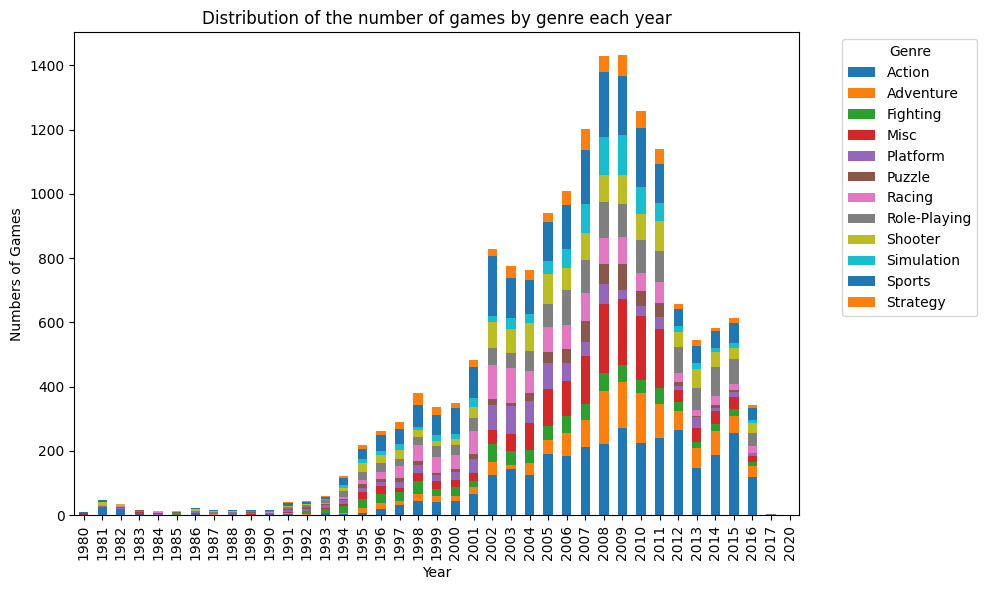

In [18]:
#每年唔同遊戲類型發佈情況
grouped_year_genre = df.groupby(['Year','Genre']).size().unstack(fill_value=0)
print (grouped_year_genre)
grouped_year_genre.plot(kind='bar',stacked = True,figsize = (10,6))
plt.title('Distribution of the number of games by genre each year')
plt.xlabel('Year')
plt.ylabel('Numbers of Games')
plt.legend(title= 'Genre',bbox_to_anchor= (1.05,1),loc = 'upper left')
plt.tight_layout()
plt.show()

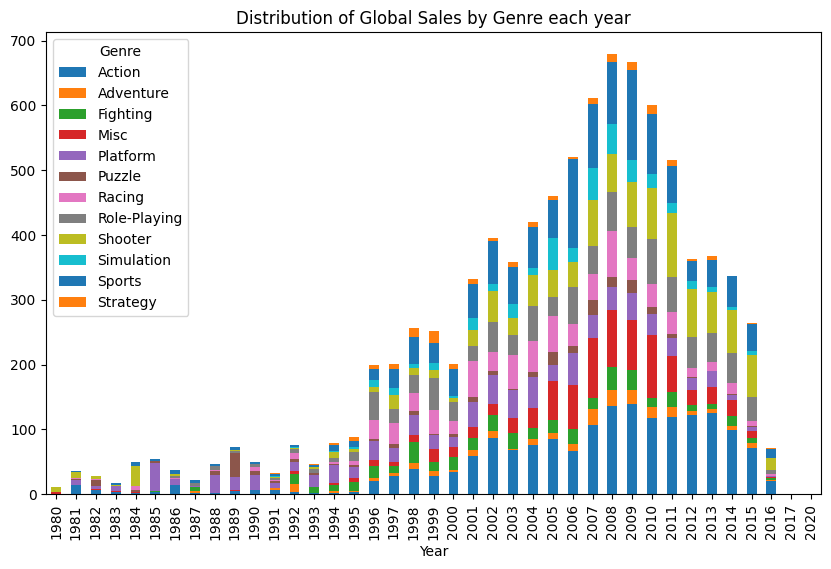

In [20]:
# 每年總銷售額(按遊戲類型)
grouped_year_genre_sales = df.groupby(['Year', 'Genre'])['Global_Sales'].sum().unstack(fill_value=0)
grouped_year_genre_sales.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.title('Distribution of Global Sales by Genre each year')
plt.show()

                                            Name Platform  Year  Global_Sales
0                                     Wii Sports      Wii  2006         82.74
1                              Super Mario Bros.      NES  1985         40.24
2                                 Mario Kart Wii      Wii  2008         35.82
3                              Wii Sports Resort      Wii  2009         33.00
4                       Pokemon Red/Pokemon Blue       GB  1996         31.37
5                                         Tetris       GB  1989         30.26
6                          New Super Mario Bros.       DS  2006         30.01
7                                       Wii Play      Wii  2006         29.02
8                      New Super Mario Bros. Wii      Wii  2009         28.62
9                                      Duck Hunt      NES  1984         28.31
10                                    Nintendogs       DS  2005         24.76
11                                 Mario Kart DS       DS  2005 

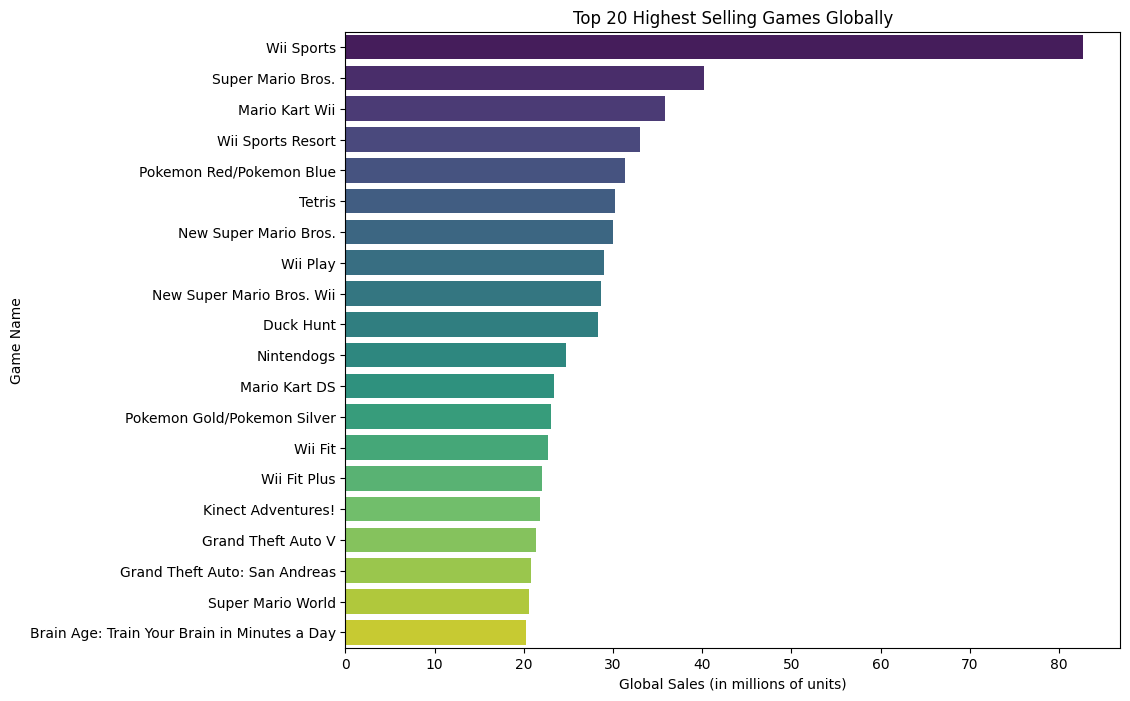

In [21]:
#頭20 hit games
top_20_games = df.sort_values(by='Global_Sales', ascending=False).head(20)

print(top_20_games[['Name', 'Platform', 'Year', 'Global_Sales']])

plt.figure(figsize=(10, 8))
sns.barplot(
    x='Global_Sales',
    y='Name',
    data=top_20_games,
    palette='viridis',
    hue='Name',
    legend=False
)

plt.title('Top 20 Highest Selling Games Globally')
plt.xlabel('Global Sales (in millions of units)')
plt.ylabel('Game Name')
plt.show()

Platform
PS2     1233.46
X360     969.61
PS3      949.35
Wii      909.81
DS       818.96
PS       727.39
GBA      313.56
PSP      291.71
PS4      278.10
PC       255.05
GB       254.42
XB       252.09
NES      251.07
3DS      246.28
N64      218.21
SNES     200.05
GC       197.14
XOne     141.06
2600      86.57
WiiU      81.86
PSV       61.63
SAT       33.59
GEN       28.36
DC        15.97
SCD        1.87
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: Global_Sales, dtype: float64


/tmp/ipykernel_3838/1456249235.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Global_Sales', y='Platform', data=sales_df, palette='Spectral')


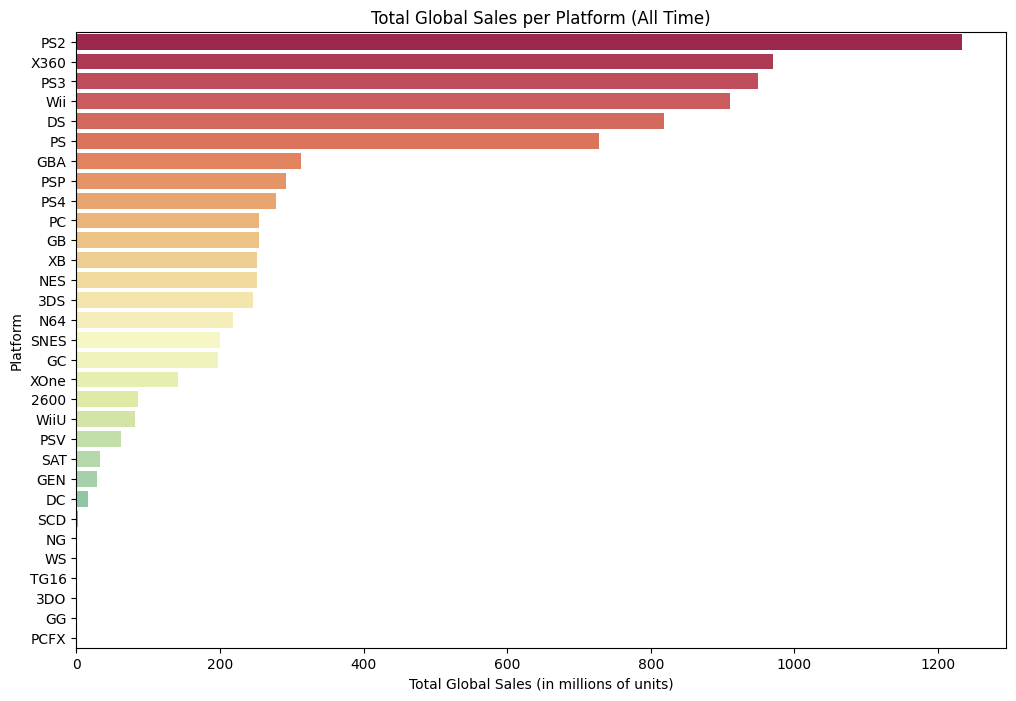

In [22]:
#唔同平台既global sales
platform_total_sales = df.groupby('Platform')['Global_Sales'].sum()

platform_total_sales = platform_total_sales.sort_values(ascending=False)

print(platform_total_sales)

sales_df = platform_total_sales.reset_index()

plt.figure(figsize=(12, 8))
sns.barplot(x='Global_Sales', y='Platform', data=sales_df, palette='Spectral')
plt.title('Total Global Sales per Platform (All Time)')
plt.xlabel('Total Global Sales (in millions of units)')
plt.ylabel('Platform')
plt.show()

Year
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     349
2001     482
2002     829
2003     775
2004     763
2005     941
2006    1008
2007    1202
2008    1428
2009    1431
2010    1259
2011    1139
2012     657
2013     546
2014     582
2015     614
2016     344
2017       3
2020       1
Name: count, dtype: int64


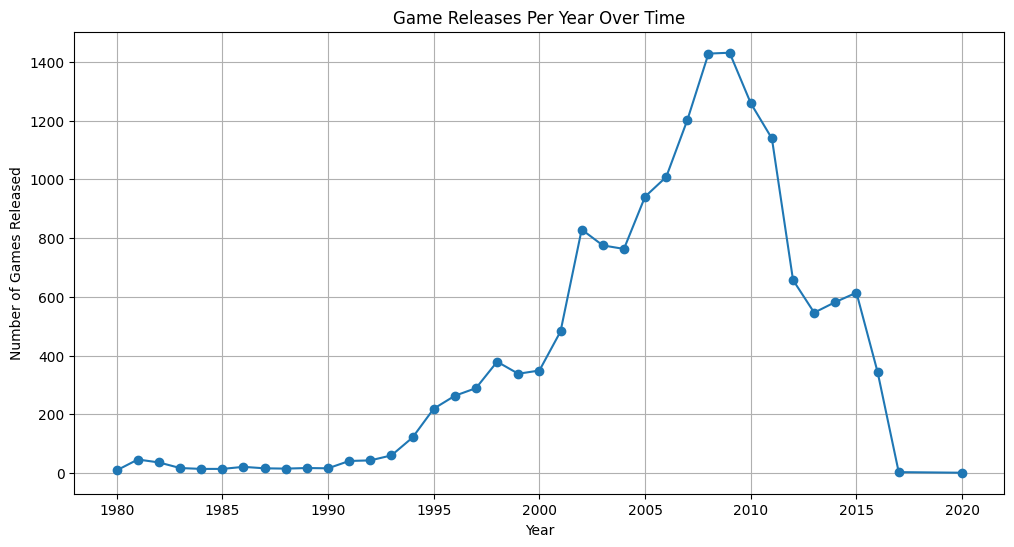

In [23]:
#每年既遊戲發佈情況
year_counts = df['Year'].value_counts().sort_index()
print (year_counts)

plt.figure(figsize=(12, 6))
plt.plot(year_counts.index, year_counts.values, marker='o')
plt.title('Game Releases Per Year Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Games Released')
plt.grid(True)
plt.show()

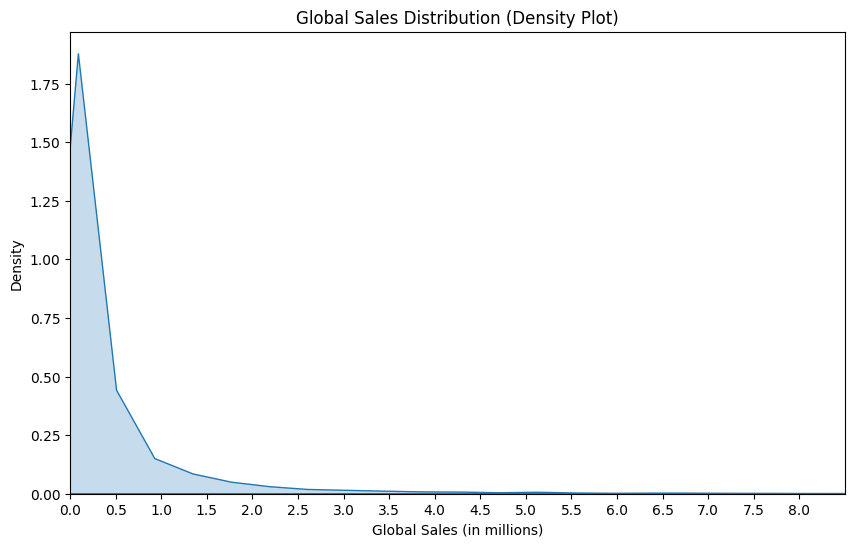

In [25]:
# #遊戲銷售既常態分佈
plt.figure(figsize=(10, 6))

sns.kdeplot(df['Global_Sales'], bw_adjust=0.5, fill=True)

plt.xlim(0, 8.5)
custom_ticks = np.arange(0, 8.5, 0.5)
plt.xticks(custom_ticks)

plt.title('Global Sales Distribution (Density Plot)')
plt.xlabel('Global Sales (in millions)')
plt.ylabel('Density')

plt.show()

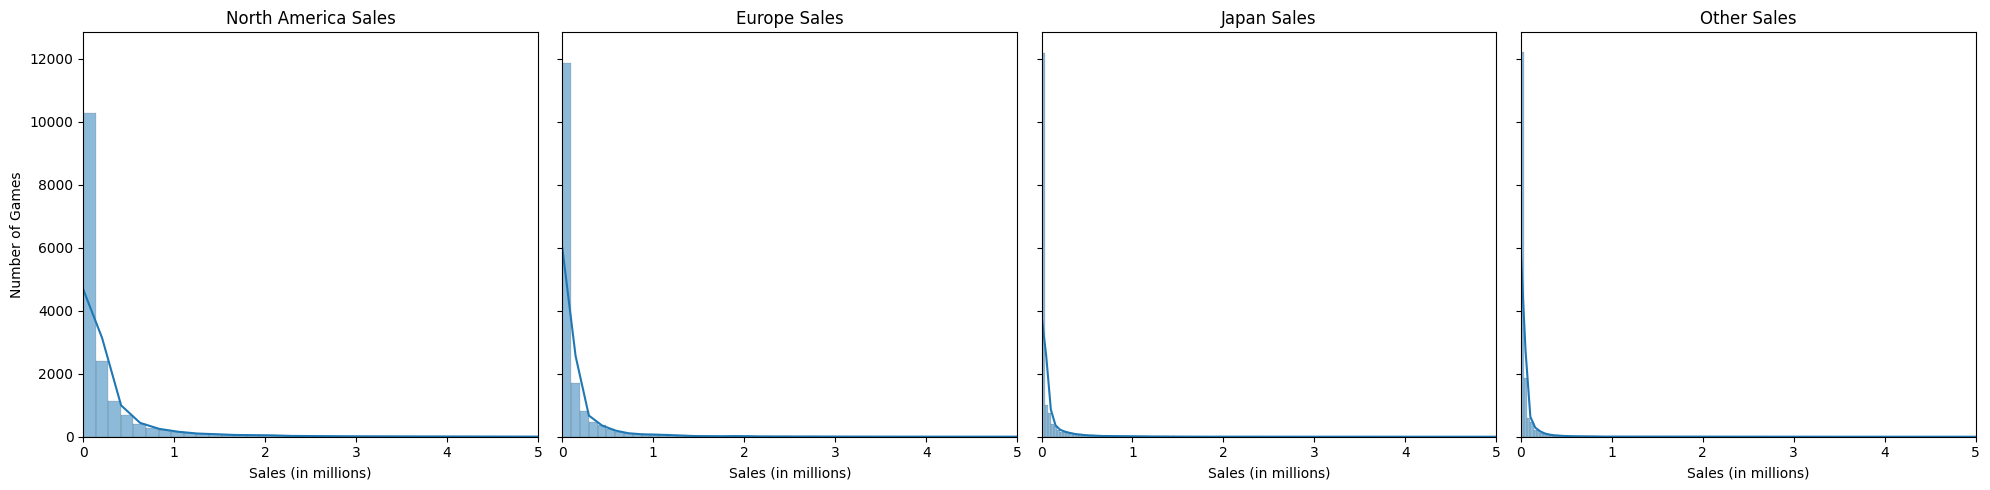

Skewness
NA_Sales       18.757935
EU_Sales       18.793824
JP_Sales       11.135809
Other_Sales    24.126108
dtype: float64

Total Sales in million
NA_Sales       4333.43
EU_Sales       2409.12
JP_Sales       1284.30
Other_Sales     789.01
dtype: float64

Describe
           NA_Sales      EU_Sales      JP_Sales   Other_Sales
count  16327.000000  16327.000000  16327.000000  16327.000000
mean       0.265415      0.147554      0.078661      0.048325
std        0.821591      0.508766      0.311557      0.189885
min        0.000000      0.000000      0.000000      0.000000
25%        0.000000      0.000000      0.000000      0.000000
50%        0.080000      0.020000      0.000000      0.010000
75%        0.240000      0.110000      0.040000      0.040000
max       41.490000     29.020000     10.220000     10.570000


In [32]:
#唔同地區銷售既常態分佈
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

sales_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
plot_titles = ['North America Sales', 'Europe Sales', 'Japan Sales', 'Other Sales']

for i, col in enumerate(sales_cols):
    sns.histplot(df[col], bins=300, kde=True, ax=axes[i])
    axes[i].set_title(plot_titles[i])
    axes[i].set_xlabel('Sales (in millions)')
    axes[i].set_xlim(0, 5)

axes[0].set_ylabel('Number of Games')

plt.tight_layout()
plt.show()
print("Skewness")
print(df[sales_cols].skew())

print("\nTotal Sales in million")
print(df[sales_cols].sum())

print("\nDescribe")
print(df[sales_cols].describe())

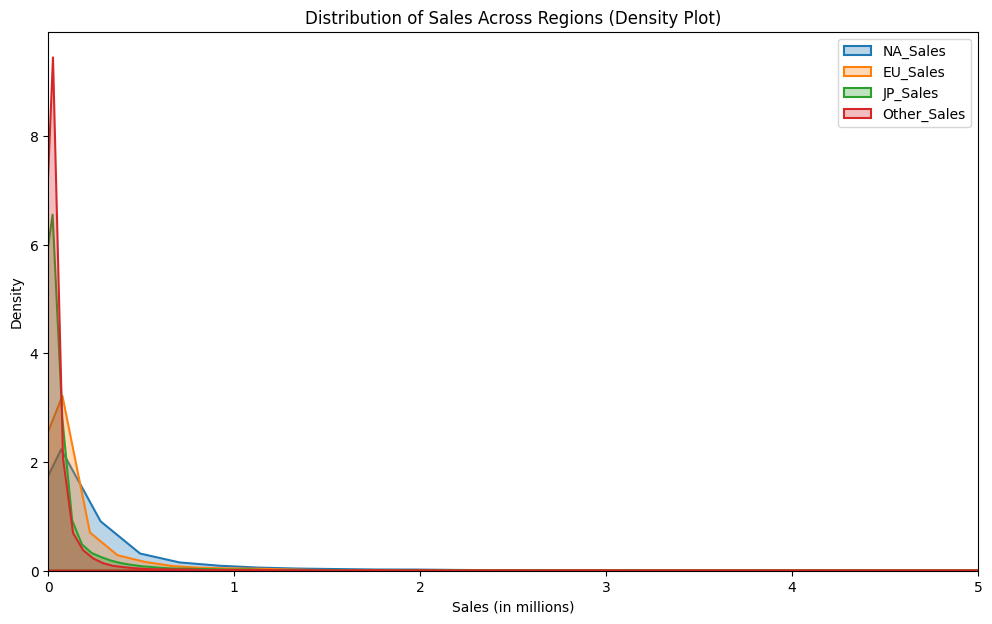

In [33]:
#一張圖show晒4個地區既常態分佈
plt.figure(figsize=(12, 7))

sns.kdeplot(df['NA_Sales'], label='NA_Sales', fill=True, alpha=0.3, linewidth=1.5)
sns.kdeplot(df['EU_Sales'], label='EU_Sales', fill=True, alpha=0.3, linewidth=1.5)
sns.kdeplot(df['JP_Sales'], label='JP_Sales', fill=True, alpha=0.3, linewidth=1.5)
sns.kdeplot(df['Other_Sales'], label='Other_Sales', fill=True, alpha=0.3, linewidth=1.5)

plt.title('Distribution of Sales Across Regions (Density Plot)')
plt.xlabel('Sales (in millions)')
plt.ylabel('Density')

plt.xlim(0, 5)

plt.legend()
plt.show()

In [34]:
genre_counts = df['Genre'].value_counts()

print("genre_counts:")
print(genre_counts)

print("in %:")
print(df['Genre'].value_counts(normalize=True) * 100)

genre_counts:
Genre
Action          3253
Sports          2304
Misc            1710
Role-Playing    1471
Shooter         1282
Adventure       1276
Racing          1226
Platform         876
Simulation       851
Fighting         836
Strategy         671
Puzzle           571
Name: count, dtype: int64
in %:
Genre
Action          19.924052
Sports          14.111594
Misc            10.473449
Role-Playing     9.009616
Shooter          7.852024
Adventure        7.815275
Racing           7.509034
Platform         5.365346
Simulation       5.212225
Fighting         5.120353
Strategy         4.109757
Puzzle           3.497274
Name: proportion, dtype: float64


/tmp/ipykernel_3838/1525968630.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=genre_summary['Count'], y=genre_summary.index, palette='viridis')


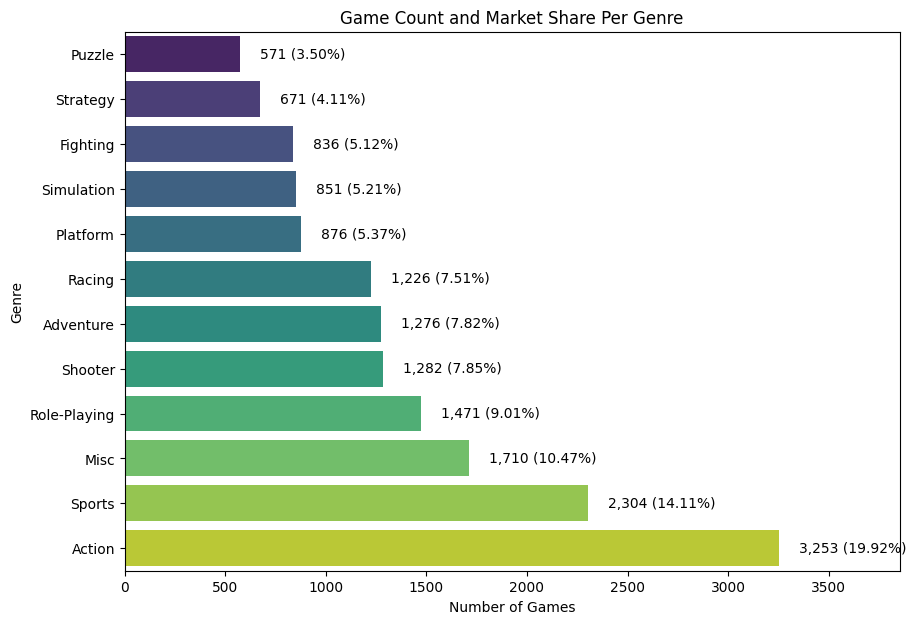

In [36]:
#各遊戲類型佔既市場比例
genre_percentages = df['Genre'].value_counts(normalize=True) * 100

genre_summary = pd.DataFrame({
    'Count': genre_counts,
    'Percentage': genre_percentages
}).sort_values(by='Count', ascending=True)

plt.figure(figsize=(10, 7))

ax = sns.barplot(x=genre_summary['Count'], y=genre_summary.index, palette='viridis')

for index, value in enumerate(genre_summary['Count']):
    percent_value = genre_summary['Percentage'].iloc[index]
    label_text = f'{value:,} ({percent_value:.2f}%)'
    ax.text(value + 100, index, label_text, va='center')

plt.title('Game Count and Market Share Per Genre')
plt.xlabel('Number of Games')
plt.ylabel('Genre')

plt.xlim(0, max(genre_summary['Count']) + 600)

plt.show()

Platform
DS      2133
PS2     2127
PS3     1304
Wii     1290
X360    1235
PSP     1197
PS      1189
PC       943
GBA      811
XB       803
GC       542
3DS      500
PSV      412
PS4      336
N64      316
SNES     239
XOne     213
SAT      173
WiiU     143
2600     116
NES       98
GB        97
DC        52
GEN       27
NG        12
SCD        6
WS         6
3DO        3
TG16       2
GG         1
PCFX       1
Name: count, dtype: int64
Platform
DS      13.064249
PS2     13.027500
PS3      7.986770
Wii      7.901023
X360     7.564158
PSP      7.331414
PS       7.282416
PC       5.775709
GBA      4.967232
XB       4.918234
GC       3.319655
3DS      3.062412
PSV      2.523427
PS4      2.057941
N64      1.935444
SNES     1.463833
XOne     1.304587
SAT      1.059595
WiiU     0.875850
2600     0.710480
NES      0.600233
GB       0.594108
DC       0.318491
GEN      0.165370
NG       0.073498
SCD      0.036749
WS       0.036749
3DO      0.018374
TG16     0.012250
GG       0.006125
PCFX     0.00

/tmp/ipykernel_3838/1900572138.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_20_platforms['Count'], y=top_20_platforms.index, palette='plasma')


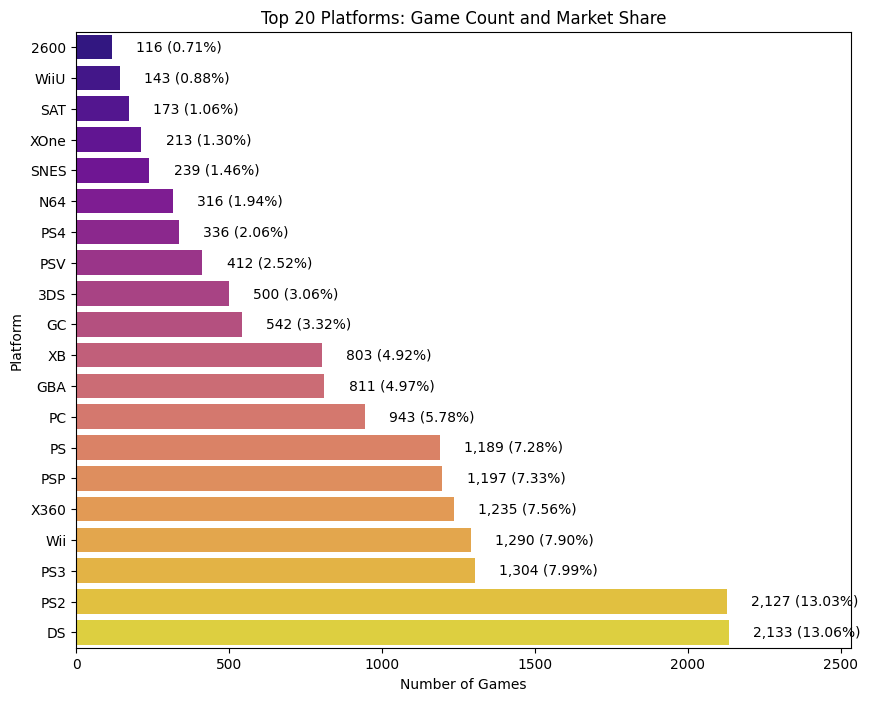

In [37]:
#頭20平台既發行遊戲數量
platform_counts = df['Platform'].value_counts()
print(platform_counts)

platform_percentages = df['Platform'].value_counts(normalize=True) * 100
print(platform_percentages)

platform_summary = pd.DataFrame({
    'Count': platform_counts,
    'Percentage': platform_percentages
}).sort_values(by='Count', ascending=True)

top_20_platforms = platform_summary.tail(20)

plt.figure(figsize=(10, 8))
ax = sns.barplot(x=top_20_platforms['Count'], y=top_20_platforms.index, palette='plasma')

for index, value in enumerate(top_20_platforms['Count']):
    percent_value = top_20_platforms['Percentage'].iloc[index]
    label_text = f'{value:,} ({percent_value:.2f}%)'
    ax.text(value + 80, index, label_text, va='center')

plt.title('Top 20 Platforms: Game Count and Market Share')
plt.xlabel('Number of Games')
plt.ylabel('Platform')
plt.xlim(0, max(top_20_platforms['Count']) + 400)
plt.show()

/tmp/ipykernel_3838/3021449060.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_15_publishers['Count'], y=top_15_publishers.index, palette='rocket')


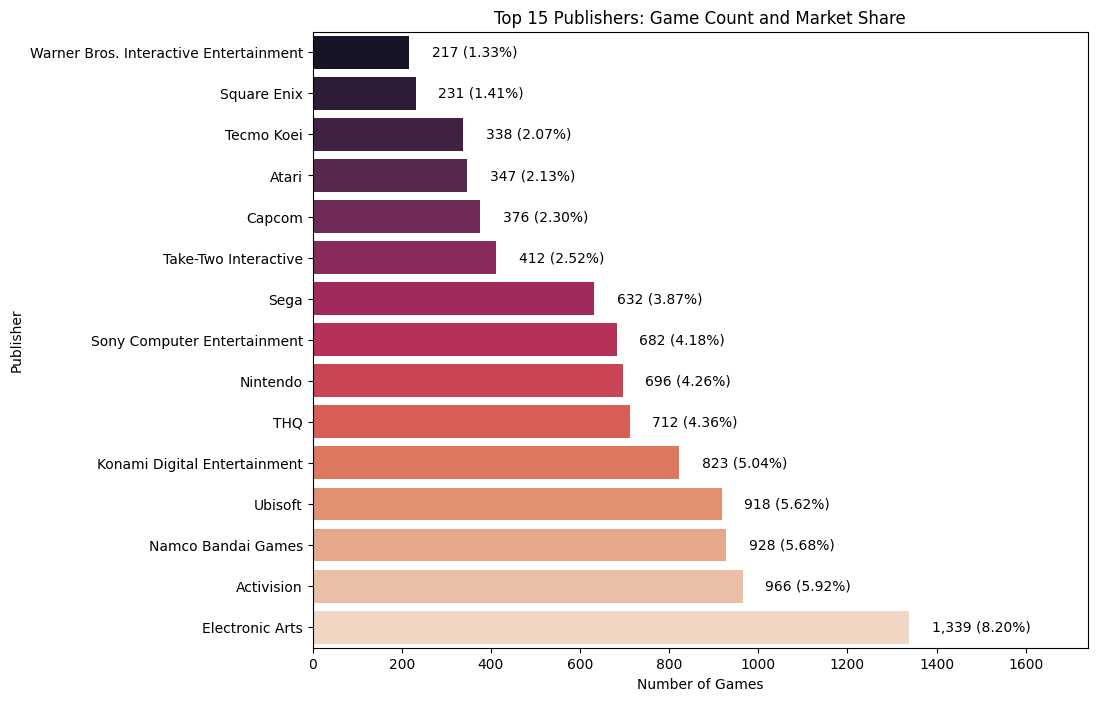

In [38]:
#頭15發行商/發行遊戲數量
publisher_counts = df['Publisher'].value_counts()
publisher_percentages = df['Publisher'].value_counts(normalize=True) * 100

publisher_summary = pd.DataFrame({
    'Count': publisher_counts,
    'Percentage': publisher_percentages
}).sort_values(by='Count', ascending=True)

top_15_publishers = publisher_summary.tail(15)

plt.figure(figsize=(10, 8))
ax = sns.barplot(x=top_15_publishers['Count'], y=top_15_publishers.index, palette='rocket')

for index, value in enumerate(top_15_publishers['Count']):
    percent_value = top_15_publishers['Percentage'].iloc[index]
    label_text = f'{value:,.0f} ({percent_value:.2f}%)'
    ax.text(value + 50, index, label_text, va='center')

plt.title('Top 15 Publishers: Game Count and Market Share')
plt.xlabel('Number of Games')
plt.ylabel('Publisher')
plt.xlim(0, max(top_15_publishers['Count']) + 400)
plt.show()

Genre
Action          1722.88
Sports          1309.24
Shooter         1026.20
Role-Playing     923.84
Platform         829.15
Misc             797.62
Racing           726.77
Fighting         444.05
Simulation       390.16
Puzzle           242.22
Adventure        234.80
Strategy         173.43
Name: Global_Sales, dtype: float64


/tmp/ipykernel_3838/1607832103.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x=genre_summary.loc[common_order]['Count'], y=genre_summary.loc[common_order].index, palette='viridis', order=common_order)
/tmp/ipykernel_3838/1607832103.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x=genre_sales_sum.loc[common_order].values, y=genre_sales_sum.loc[common_order].index, palette='plasma', order=common_order)


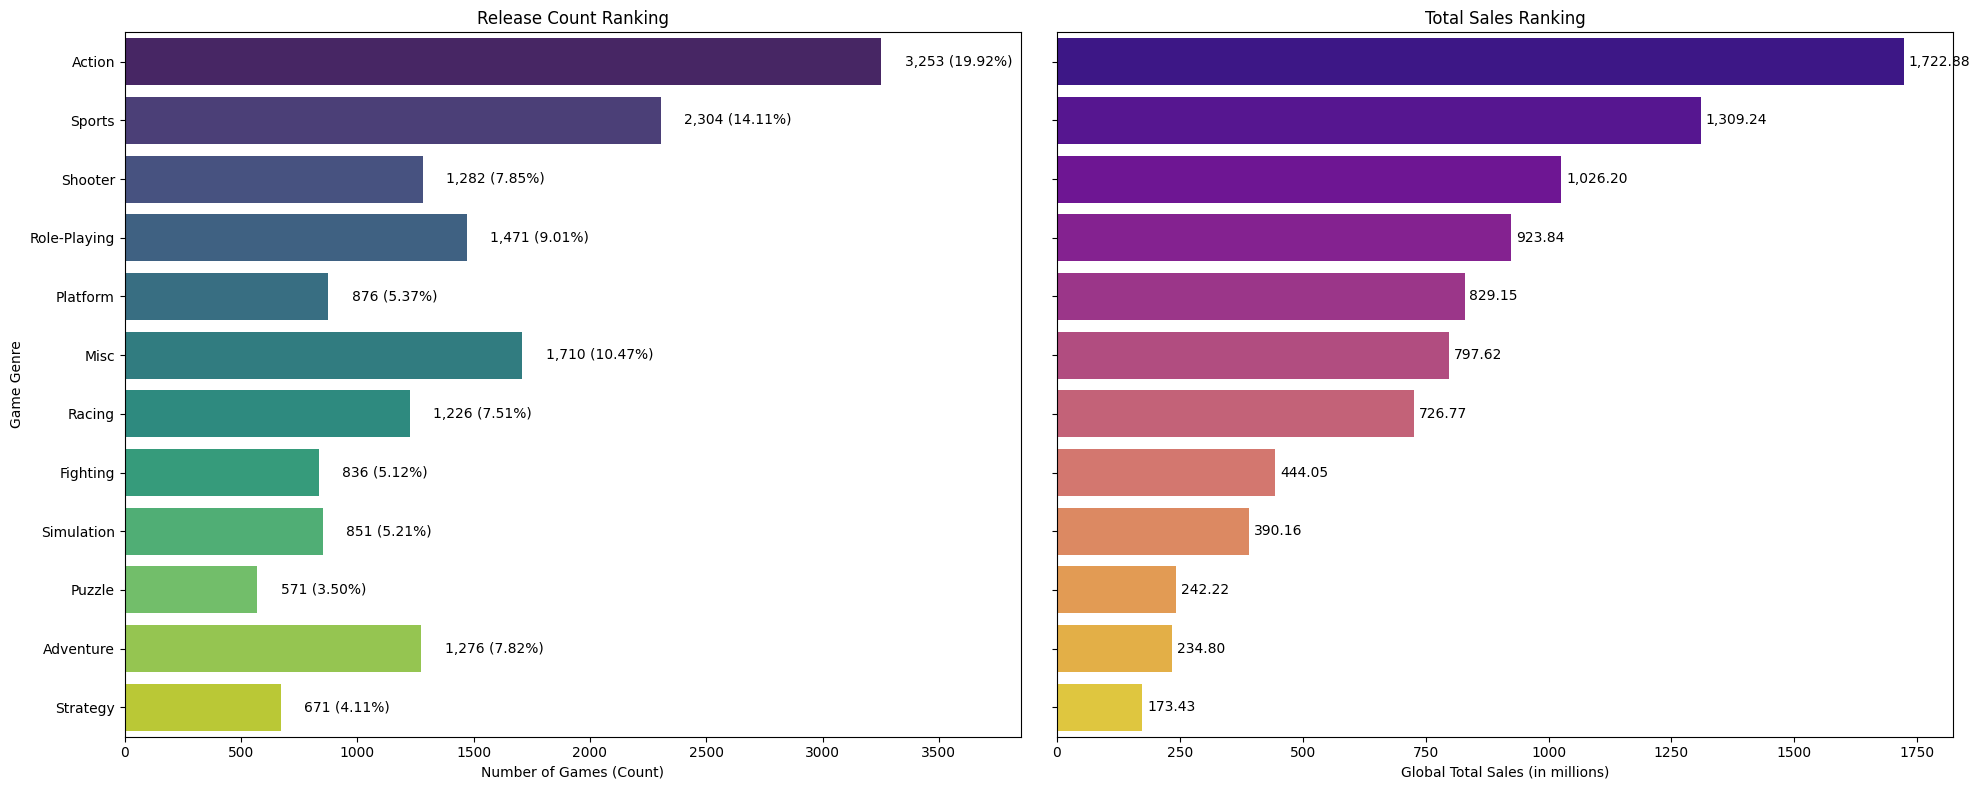

In [44]:
#各類型發行數目/銷售數量
genre_summary = pd.DataFrame({
    'Count': genre_counts,
    'Percentage': genre_percentages
}).sort_values(by='Count', ascending=False)

genre_sales_sum = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
print (genre_sales_sum)

common_order = genre_sales_sum.index

fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

sns.barplot(ax=axes[0], x=genre_summary.loc[common_order]['Count'], y=genre_summary.loc[common_order].index, palette='viridis', order=common_order)
axes[0].set_title('Release Count Ranking')
axes[0].set_xlabel('Number of Games (Count)')
axes[0].set_ylabel('Game Genre')

for index, value in enumerate(genre_summary.loc[common_order]['Count']):
    percent_value = genre_summary.loc[common_order]['Percentage'].iloc[index]
    label_text = f'{value:,.0f} ({percent_value:.2f}%)'
    axes[0].text(value + 100, index, label_text, va='center')

axes[0].set_xlim(0, max(genre_summary['Count']) + 600)

sns.barplot(ax=axes[1], x=genre_sales_sum.loc[common_order].values, y=genre_sales_sum.loc[common_order].index, palette='plasma', order=common_order)
axes[1].set_title('Total Sales Ranking')
axes[1].set_xlabel('Global Total Sales (in millions)')
axes[1].set_ylabel('')

for index, value in enumerate(genre_sales_sum.loc[common_order].values):
    label_text = f'{value:,.2f}'
    axes[1].text(value + 10, index, label_text, va='center')

axes[1].set_xlim(0, max(genre_sales_sum.values) + 100)

plt.tight_layout()
plt.show()

                              Total_Sales_M  Game_Count  Average_Sales_M
Publisher                                                               
Nintendo                            1784.43         696         2.563836
Electronic Arts                     1093.39        1339         0.816572
Activision                           721.41         966         0.746801
Sony Computer Entertainment          607.28         682         0.890440
Ubisoft                              473.54         918         0.515839
Take-Two Interactive                 399.30         412         0.969175
THQ                                  340.44         712         0.478146
Konami Digital Entertainment         278.56         823         0.338469
Sega                                 270.70         632         0.428323
Namco Bandai Games                   253.65         928         0.273330


/tmp/ipykernel_3838/1319072411.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 0], x=top_10_publishers['Total_Sales_M'], y=order, palette='plasma', order=order)
/tmp/ipykernel_3838/1319072411.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 1], x=top_10_publishers['Game_Count'], y=order, palette='viridis', order=order)
/tmp/ipykernel_3838/1319072411.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1, 0], x=top_10_publishers['Average_Sales_M'], y=order, palette='magma', order=order)


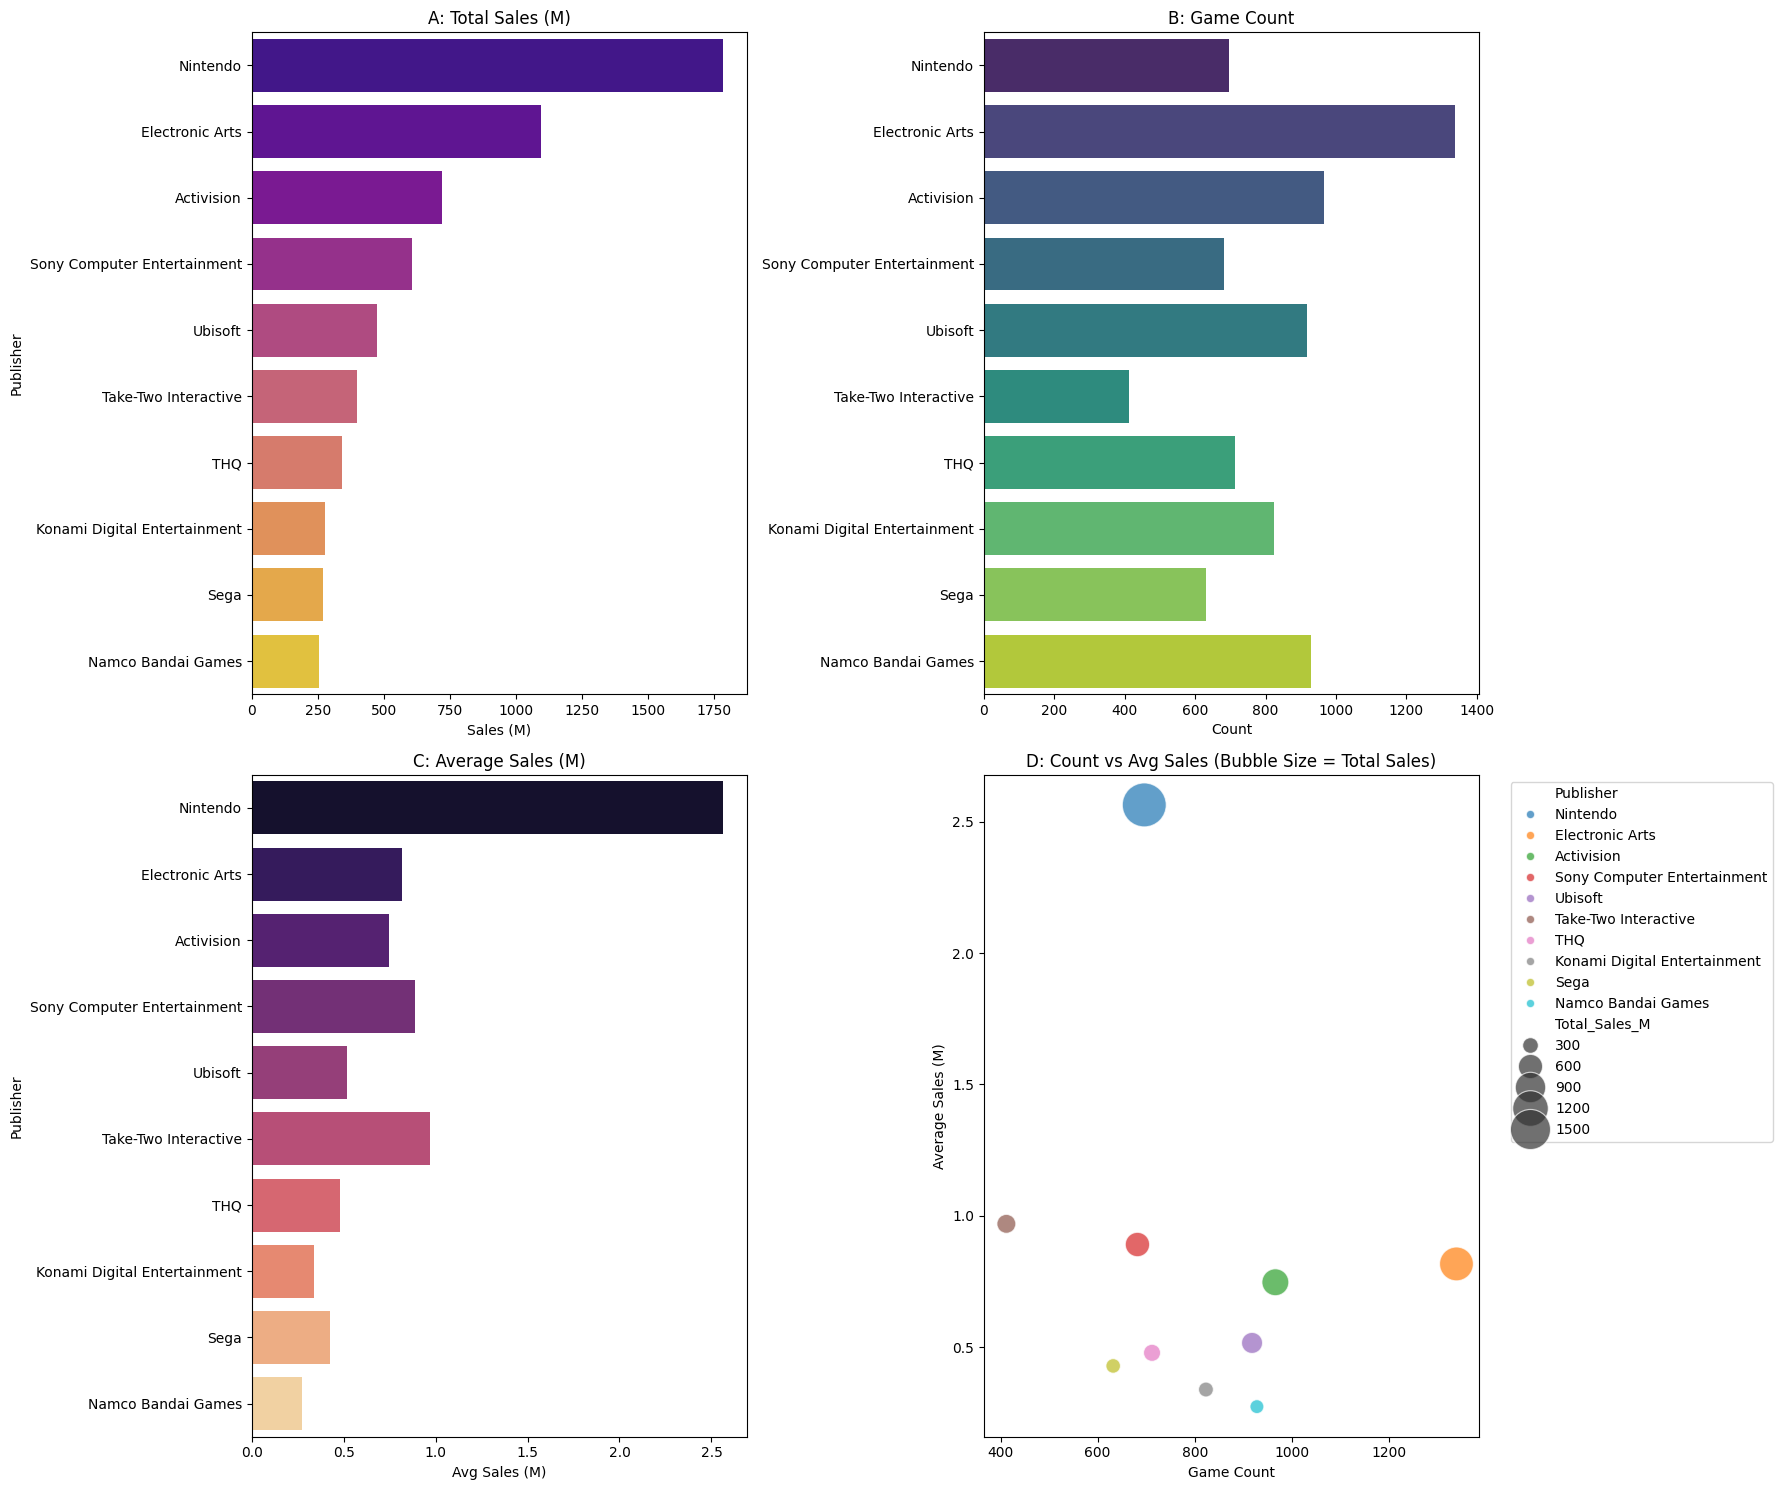

In [43]:
#2x2圖
publisher_total_sales = df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False)
publisher_counts = df['Publisher'].value_counts()
publisher_avg_sales = df.groupby('Publisher')['Global_Sales'].mean()

publisher_summary = pd.DataFrame({
    'Total_Sales_M': publisher_total_sales,
    'Game_Count': publisher_counts,
    'Average_Sales_M': publisher_avg_sales})

publisher_summary = publisher_summary.sort_values(by='Total_Sales_M', ascending=False)

top_10_publishers = publisher_summary.head(10)
print(top_10_publishers)

fig, axes = plt.subplots(2, 2, figsize=(18, 15))
order = top_10_publishers.index

sns.barplot(ax=axes[0, 0], x=top_10_publishers['Total_Sales_M'], y=order, palette='plasma', order=order)
axes[0, 0].set_title('A: Total Sales (M)')
axes[0, 0].set_xlabel('Sales (M)')

sns.barplot(ax=axes[0, 1], x=top_10_publishers['Game_Count'], y=order, palette='viridis', order=order)
axes[0, 1].set_title('B: Game Count')
axes[0, 1].set_xlabel('Count')
axes[0, 1].set_ylabel('')

sns.barplot(ax=axes[1, 0], x=top_10_publishers['Average_Sales_M'], y=order, palette='magma', order=order)
axes[1, 0].set_title('C: Average Sales (M)')
axes[1, 0].set_xlabel('Avg Sales (M)')

sns.scatterplot(ax=axes[1, 1], data=top_10_publishers, x='Game_Count', y='Average_Sales_M',
                size='Total_Sales_M', hue=top_10_publishers.index, sizes=(100, 1000), alpha=0.7)
axes[1, 1].set_title('D: Count vs Avg Sales (Bubble Size = Total Sales)')
axes[1, 1].set_xlabel('Game Count')
axes[1, 1].set_ylabel('Average Sales (M)')
axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Genre                         Action  Adventure  Fighting  Misc  Platform  \
Publisher                                                                   
All                             1623        373       374   852       529   
Electronic Arts                  182         13        38    43        16   
Activision                       308         25         7   103        60   
Namco Bandai Games               247         58       134    97        19   
Ubisoft                          193         59        18   151        70   
Konami Digital Entertainment     143         52        20    75        40   
THQ                              193         47        71    66        84   
Nintendo                          78         35        18   100       111   
Sony Computer Entertainment       90         41        30   128        66   
Sega                              96         31        37    62        52   
Take-Two Interactive              93         12         1    27        11   

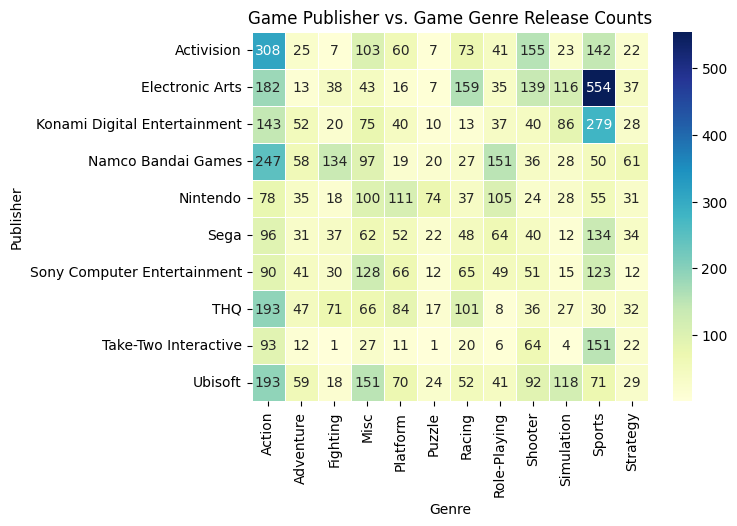

In [42]:
#heatmap
top_10_publishers_names = ['Nintendo', 'Electronic Arts', 'Activision', 'Sony Computer Entertainment', 'Ubisoft', 'Take-Two Interactive', 'THQ', 'Konami Digital Entertainment', 'Sega', 'Namco Bandai Games']
df_top10 = df[df['Publisher'].isin(top_10_publishers_names)]
publisher_genre_counts = pd.crosstab(df_top10['Publisher'], df_top10['Genre'], margins=True)

publisher_genre_counts = publisher_genre_counts.sort_values(by='All', ascending=False)

print(publisher_genre_counts)

heatmap_data = pd.crosstab(df_top10['Publisher'], df_top10['Genre'])

sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt='d', linewidths=.5)

plt.title('Game Publisher vs. Game Genre Release Counts')
plt.xlabel('Genre')
plt.ylabel('Publisher')
plt.show()

Number of Games with sales exceeding 2.0M: 836

Hit game(>2M) genre distribution:
Genre
Action          173
Sports          116
Shooter         109
Role-Playing     95
Platform         85
Misc             73
Racing           65
Fighting         42
Simulation       33
Puzzle           20
Adventure        13
Strategy         12
Name: count, dtype: int64

Hit game(>2M) genre persentage:
Genre
Action          20.693780
Sports          13.875598
Shooter         13.038278
Role-Playing    11.363636
Platform        10.167464
Misc             8.732057
Racing           7.775120
Fighting         5.023923
Simulation       3.947368
Puzzle           2.392344
Adventure        1.555024
Strategy         1.435407
Name: proportion, dtype: float64


/tmp/ipykernel_3838/1975764877.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hit_game_genre_counts.values, y=hit_game_genre_counts.index, palette='plasma', order=hit_game_genre_counts.index)


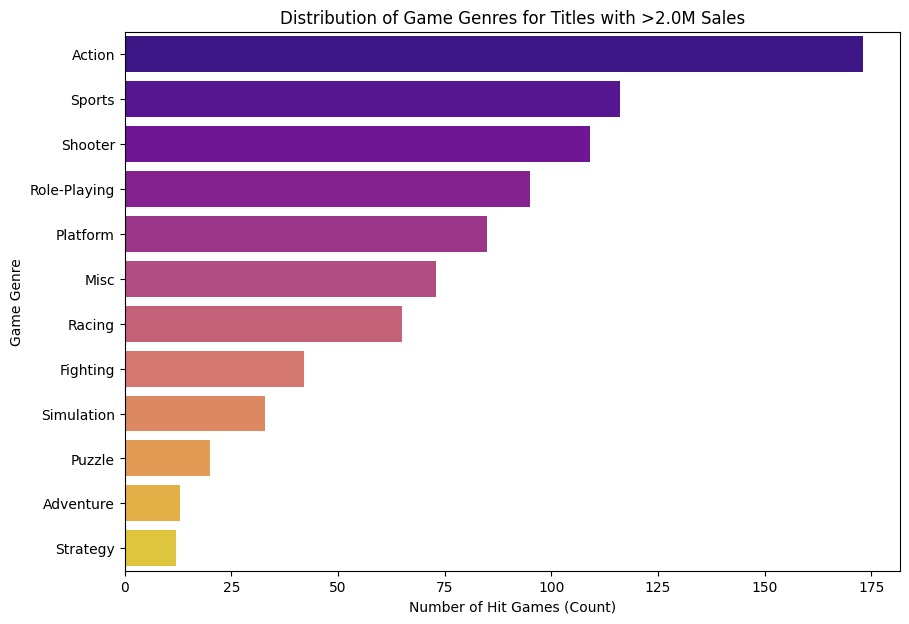

In [50]:
#各遊戲類型hitgames數量
SALES_THRESHOLD = 2.0
hit_games = df[df['Global_Sales'] > SALES_THRESHOLD]
print(f"Number of Games with sales exceeding {SALES_THRESHOLD}M: {len(hit_games)}")

hit_game_genre_counts = hit_games['Genre'].value_counts()
print("\nHit game(>2M) genre distribution:")
print(hit_game_genre_counts)

hit_game_genre_pct = hit_games['Genre'].value_counts(normalize=True) * 100
print("\nHit game(>2M) genre persentage:")
print(hit_game_genre_pct)

plt.figure(figsize=(10, 7))

sns.barplot(x=hit_game_genre_counts.values, y=hit_game_genre_counts.index, palette='plasma', order=hit_game_genre_counts.index)

plt.title(f'Distribution of Game Genres for Titles with >{SALES_THRESHOLD}M Sales')
plt.xlabel('Number of Hit Games (Count)')
plt.ylabel('Game Genre')

plt.show()

Genre                         Action  Adventure  Fighting  Misc  Platform  \
Publisher                                                                   
Nintendo                          21          3         8    25        50   
Electronic Arts                    8          0         0     2         0   
Activision                         9          0         0     8         2   
Sony Computer Entertainment       15          1         4     5        18   
Ubisoft                           22          2         0    10         1   
Take-Two Interactive              20          2         0     2         0   
THQ                                9          1        10     1         1   
Konami Digital Entertainment       8          0         0     1         0   
Sega                               1          0         0     3         9   
Namco Bandai Games                 0          0         5     2         0   

Genre                         Puzzle  Racing  Role-Playing  Shooter  \
Publ

<Figure size 1200x1000 with 0 Axes>

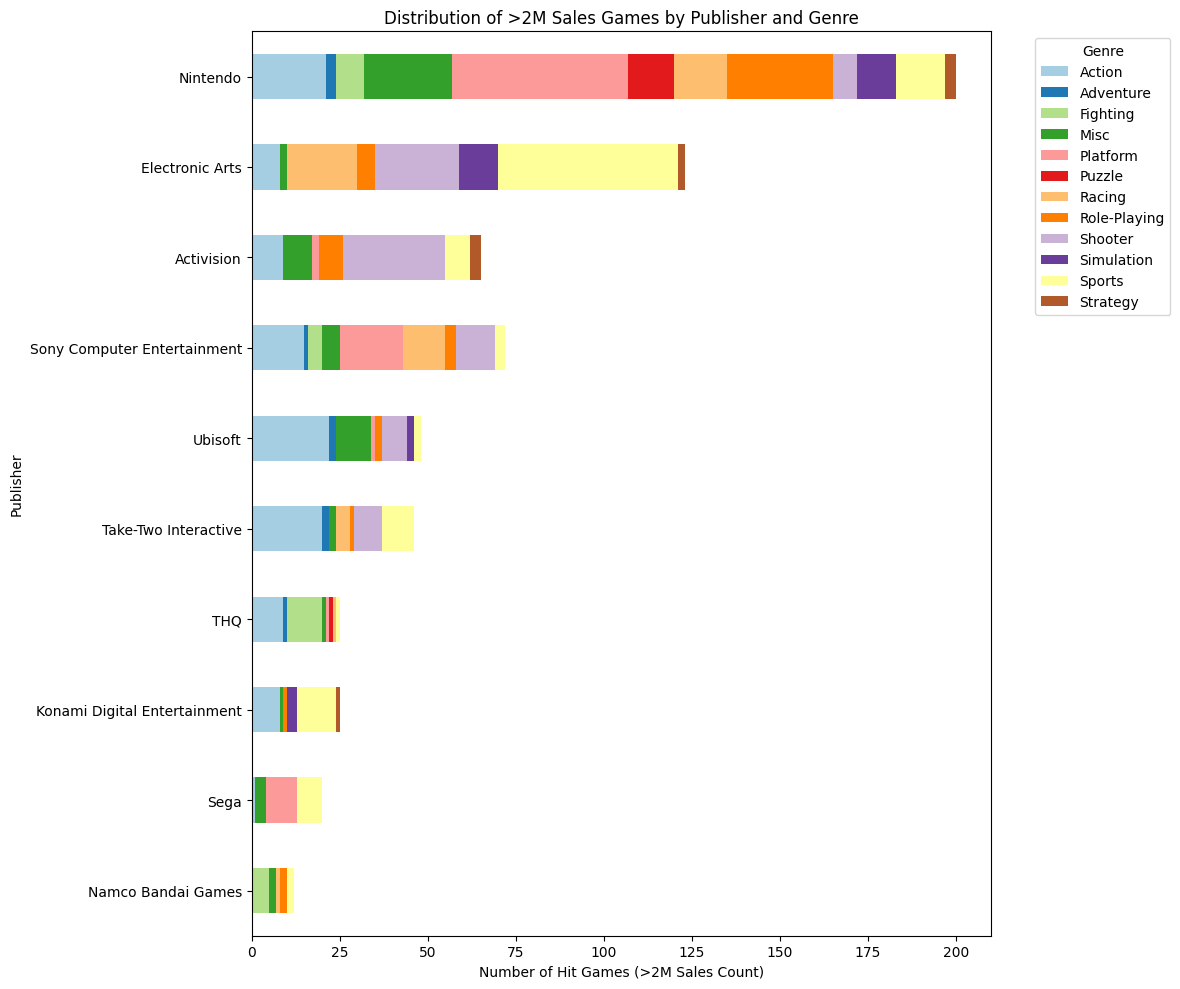

In [52]:
#頭10發行商中的hitgames數量及類型
hit_games_top10 = hit_games[hit_games['Publisher'].isin(top_10_publishers_names)]
publisher_genre_counts_hit = hit_games_top10.groupby(['Publisher', 'Genre']).size().unstack(fill_value=0)
publisher_genre_counts_hit['Total_Hit_Games'] = publisher_genre_counts_hit.sum(axis=1)
final_table = publisher_genre_counts_hit.reindex(top_10_publishers_names)
final_table = final_table.fillna(0)
print(final_table)

plot_data = final_table.drop(columns=['Total_Hit_Games'])
plt.figure(figsize=(12, 10))

ax = plot_data.plot(kind='barh', stacked=True, figsize=(12, 10), colormap='Paired')
ax.invert_yaxis()

plt.title('Distribution of >2M Sales Games by Publisher and Genre')
plt.xlabel('Number of Hit Games (>2M Sales Count)')
plt.ylabel('Publisher')

ax.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

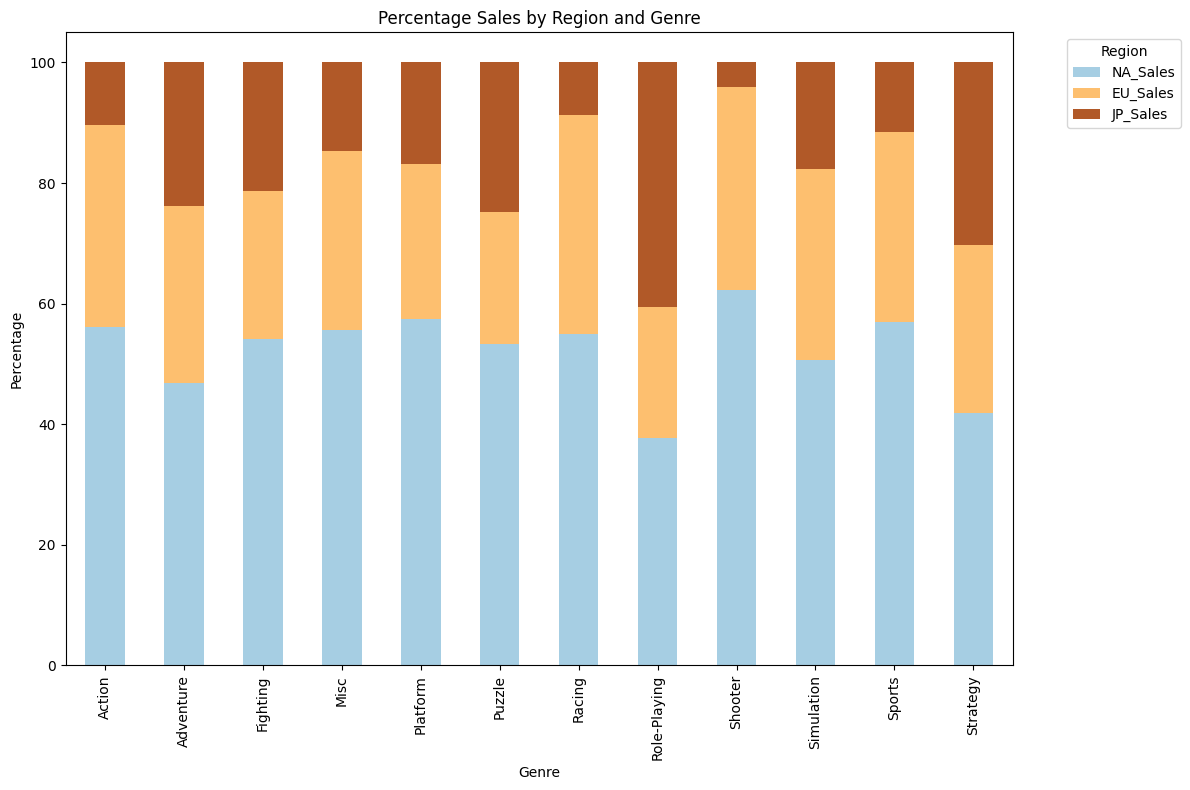

In [54]:
#三地區的類型銷售情況
regional_genre_sales = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales']].sum()

regional_genre_sales_pct = regional_genre_sales.div(regional_genre_sales.sum(axis=1), axis=0) * 100

ax = regional_genre_sales_pct.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='Paired')

plt.title('Percentage Sales by Region and Genre')
plt.xlabel('Genre')
plt.ylabel('Percentage')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

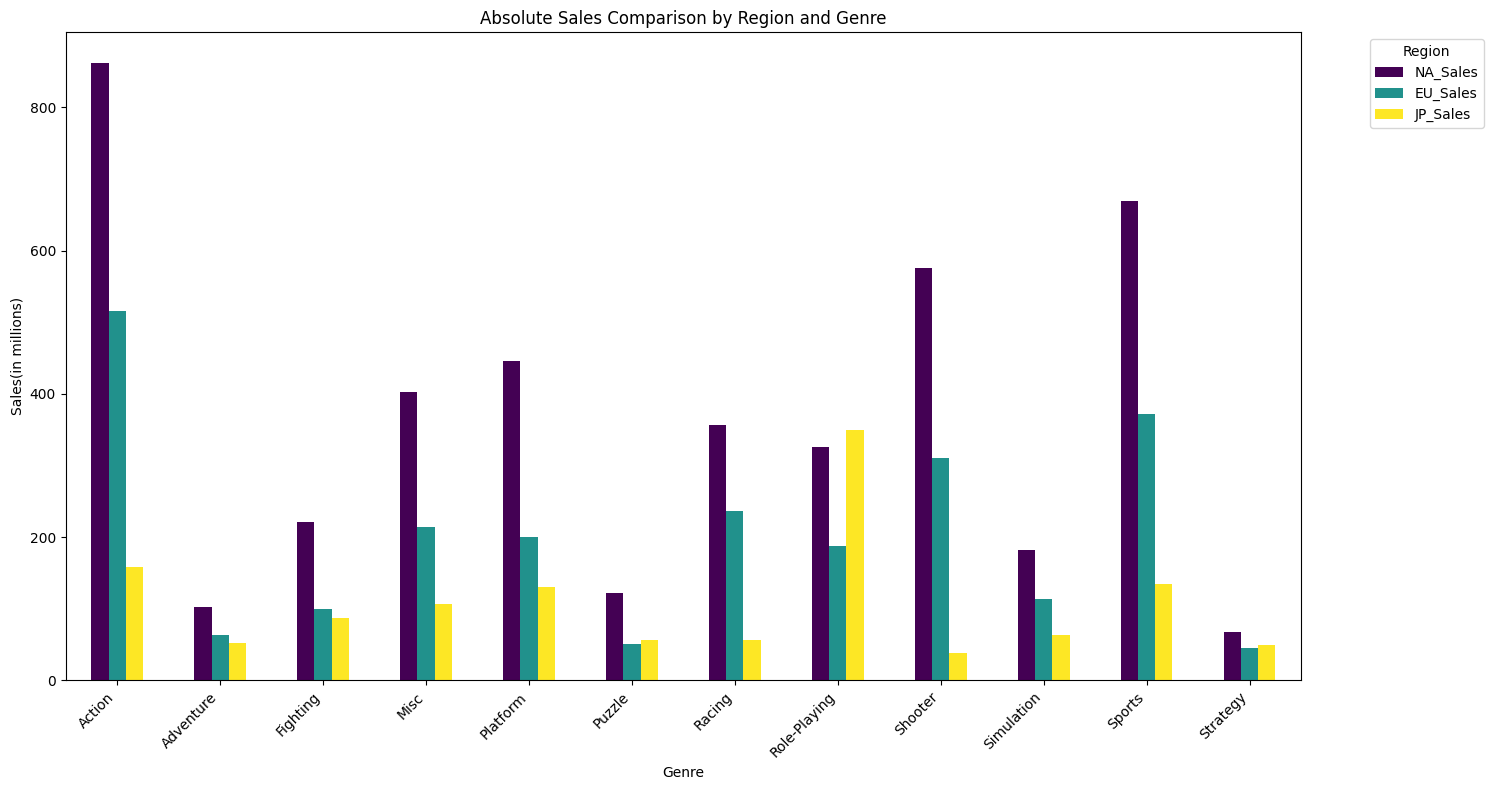

In [56]:
#同上
ax = regional_genre_sales.plot(kind='bar', figsize=(15, 8), colormap='viridis')

plt.title('Absolute Sales Comparison by Region and Genre')
plt.xlabel('Genre')
plt.ylabel('Sales(in millions)')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

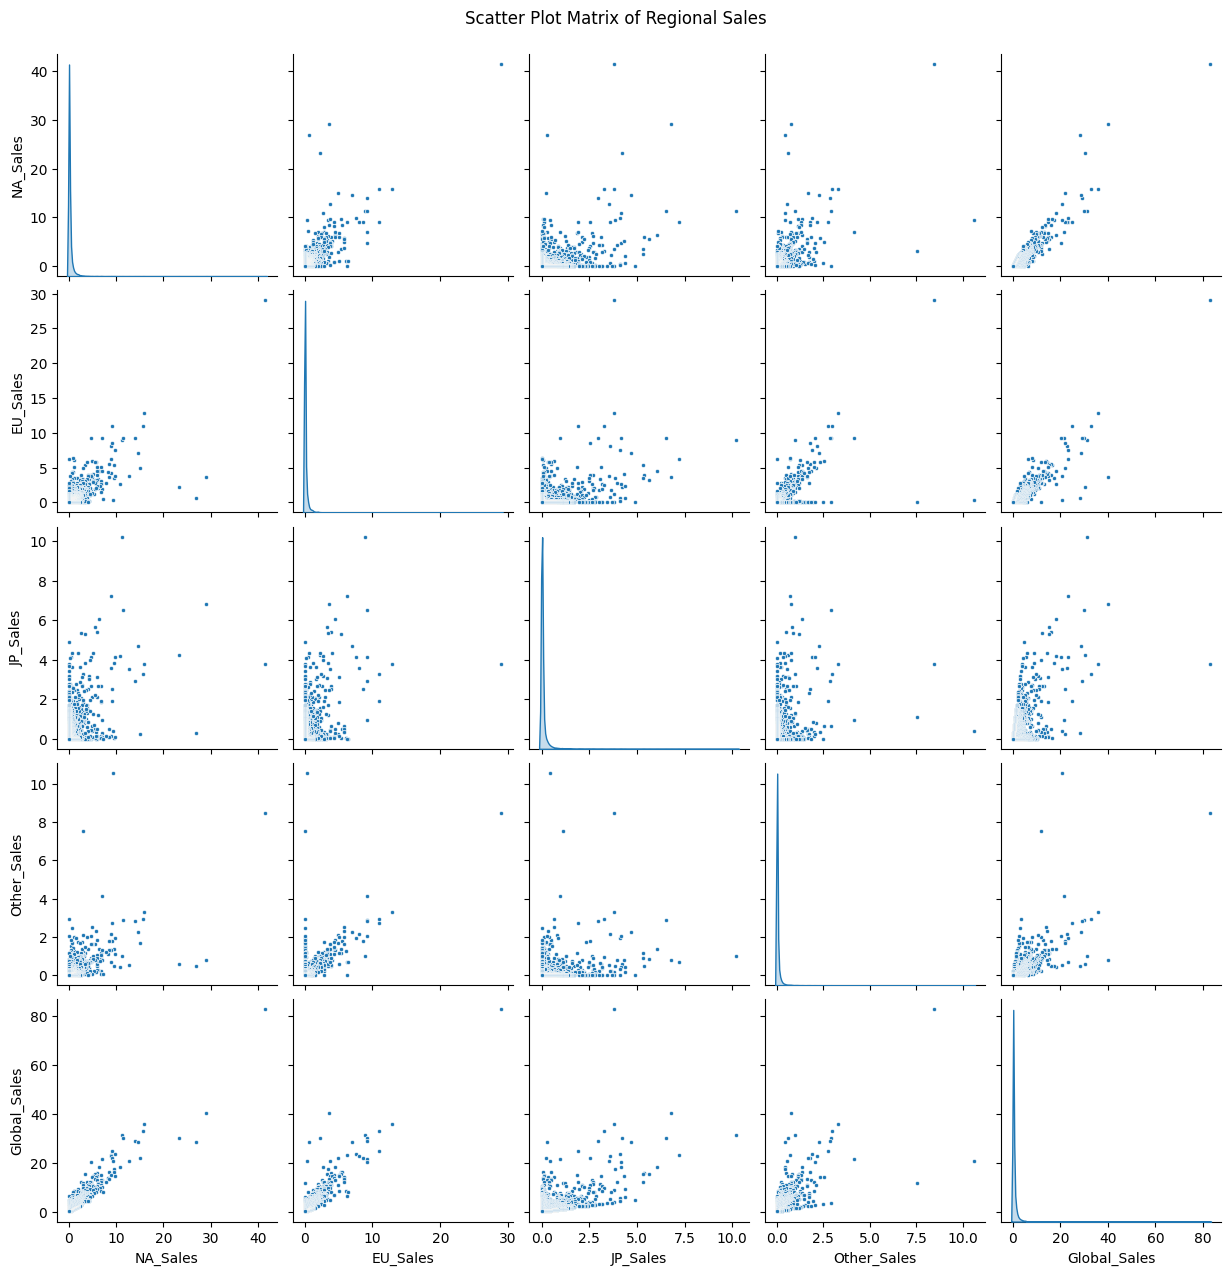

In [57]:
#Scatter plot 同上
plt.figure(figsize=(10, 8))

df_sales = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']]
sns.pairplot(df_sales, diag_kind='kde', markers='.')
plt.suptitle('Scatter Plot Matrix of Regional Sales', y=1.02)
plt.show()
